In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [21]:
base_credit = pd.read_csv("C:/Users/preaes/curso-machine-learning/bases_dados/credit_data.csv")

display(base_credit)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [22]:
base_credit.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [23]:
base_credit[base_credit['income'] >= 69995.685578]

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [24]:
base_credit[base_credit['loan'] <= 1.377630]

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


In [25]:
np.unique(base_credit['default'], return_counts='True')

(array([0, 1]), array([1717,  283]))

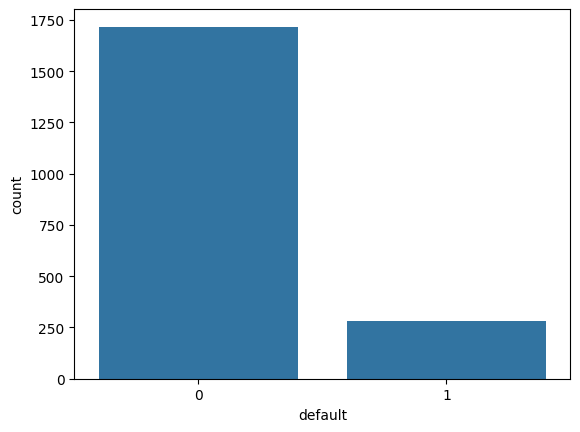

In [26]:
sns.countplot(x = base_credit['default']);

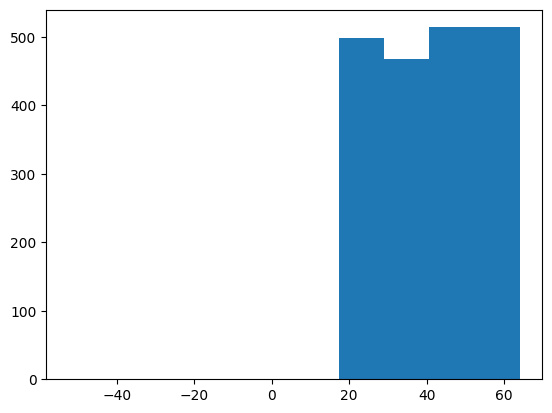

In [27]:
plt.hist(x = base_credit['age']);

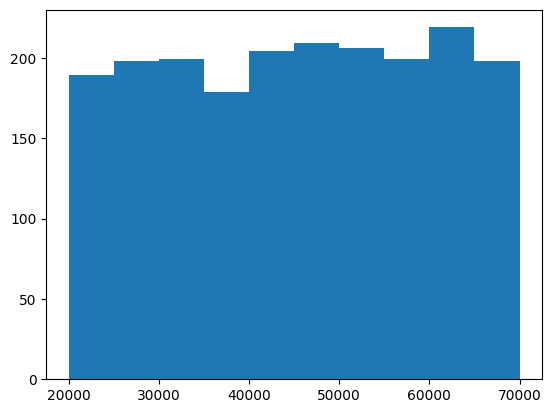

In [28]:
plt.hist(base_credit['income']);

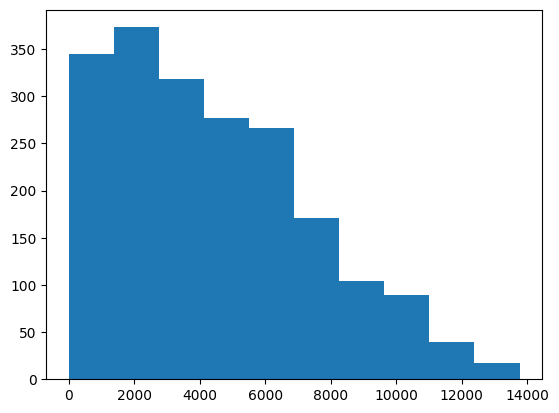

In [29]:
plt.hist(base_credit['loan']);

In [30]:
#grafico = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'])
#grafico.show()

In [31]:
base_credit.loc[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [32]:
base_credit[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


# Apagar a coluna inteira (de todos os registros de dados)

In [33]:
base_credit2 = base_credit.drop('age', axis=1)
base_credit2

,clientid,income,loan,default
0,1,66155.925095,8106.532131,0
1,2,34415.153966,6564.745018,0
2,3,57317.170063,8020.953296,0
3,4,42709.534201,6103.642260,0
4,5,66952.688845,8770.099235,1
...,...,...,...,...
1995,1996,59221.044874,1926.729397,0
1996,1997,69516.127573,3503.176156,0
1997,1998,44311.449262,5522.786693,1
1998,1999,43756.056605,1622.722598,0


# Apagar somento os registros com valores inconsistentes

In [34]:
base_credit.index # são os índices. Na linha abaixo, dizemos que queremos apagar os "índices" com idade negativa

RangeIndex(start=0, stop=2000, step=1)

In [35]:
base_credit3 = base_credit.drop(base_credit[base_credit['age'] < 0].index)
base_credit3

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [36]:
base_credit3.loc[base_credit3['age'] < 0]

,clientid,income,age,loan,default


# Preenches os valores inconsistentes manualmente

In [37]:
base_credit.mean()

clientid     1000.500000
income      45331.600018
age            40.807559
loan         4444.369695
default         0.141500
dtype: float64

In [38]:
base_credit['age'][base_credit['age'] > 0].mean()

np.float64(40.92770044906149)

In [39]:
base_credit.loc[base_credit['age'] < 0, 'age'] = 40.92
base_credit[base_credit['age'] < 0]
base_credit.head(27)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


# Tratamento de valores faltantes

In [40]:
base_credit.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

In [41]:
base_credit.loc[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [42]:
base_credit['age'].fillna(base_credit['age'].mean(), inplace=True) # usar o Inplace para substituir as mudanças na base de dados
base_credit.loc[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default


In [43]:
base_credit.loc[base_credit['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


In [44]:
x_credit = base_credit.iloc[:, 1:4].values
y_credit = base_credit.iloc[:, 4].values

In [45]:
print(x_credit)
type(x_credit)

[[6.61559251e+04 5.90170151e+01 8.10653213e+03]
 [3.44151540e+04 4.81171531e+01 6.56474502e+03]
 [5.73171701e+04 6.31080495e+01 8.02095330e+03]
 ...
 [4.43114493e+04 2.80171669e+01 5.52278669e+03]
 [4.37560566e+04 6.39717958e+01 1.62272260e+03]
 [6.94365796e+04 5.61526170e+01 7.37883360e+03]]


numpy.ndarray

In [46]:
print(y_credit)
type(y_credit)

[0 0 0 ... 1 0 0]


numpy.ndarray

# Escalonamento: 
para deixar os valores na mesma escala para não afetar a precisão dos algoritmos preditivos
    Padronização x = (x - media(x)) / desvio padrao(x) ---- Mais indicado para quando temos outliers na base
    Normalização (x - minimo(x)) / maximo(x) - minimo(x)

In [47]:
print(x_credit[:, 0].min())
print(x_credit[:, 0].max())

20014.4894700497
69995.6855783239


In [48]:
print(x_credit[:, 1].min())
print(x_credit[:, 1].max())

18.055188510566897
63.971795841120205


In [49]:
print(x_credit[:, 2].min())
print(x_credit[:, 2].max())

1.37762959325451
13766.0512393337


In [50]:
from sklearn.preprocessing import StandardScaler

scaler_credit = StandardScaler()
x_credit = scaler_credit.fit_transform(x_credit)
x_credit

array([[ 1.45393393,  1.36538093,  1.20281942],
       [-0.76217555,  0.5426602 ,  0.69642695],
       [ 0.83682073,  1.67417189,  1.17471147],
       ...,
       [-0.07122592, -0.97448519,  0.35420081],
       [-0.11000289,  1.73936739, -0.92675625],
       [ 1.682986  ,  1.14917639,  0.96381038]], shape=(2000, 3))

In [51]:
x_credit[:, 0].min(), x_credit[:, 1].min(), x_credit[:, 2].min()

(np.float64(-1.7676158019964077),
 np.float64(-1.7264145408889917),
 np.float64(-1.4592791099462408))

In [52]:
x_credit[:, 0].max(), x_credit[:, 1].max(), x_credit[:, 2].max()

(np.float64(1.7220222385319197),
 np.float64(1.7393673928651967),
 np.float64(3.0616609141708273))

# Divisão entre bases de treinamento e teste

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
# random_state para fixar os mesmos registros nas bases de treinamento e teste
x_credit_treinamento, x_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(x_credit, y_credit, test_size=0.25, random_state=0)

In [55]:
x_credit_treinamento.shape

(1500, 3)

In [56]:
y_credit_treinamento.shape

(1500,)

In [57]:
x_credit_teste.shape, y_credit_teste.shape

((500, 3), (500,))

# Tunning

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [59]:
x_credit = np.concatenate((x_credit_treinamento, x_credit_teste), axis=0)
x_credit.shape

(2000, 3)

In [60]:
y_credit = np.concatenate((y_credit_treinamento, y_credit_teste), axis=0)
y_credit.shape

(2000,)

# Árvpre de Decisão

In [61]:
parametros = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [62]:
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'criterion': 'gini', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
0.983


# Random Forest

In [63]:
parametros = {'criterion': ['gini', 'entropy'],
              'n_estimators': [10, 40, 100, 150],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [64]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
0.9860000000000001


# K Neighboors Classifier

In [65]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p': [1, 2]}

In [66]:
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'n_neighbors': 20, 'p': 1}
0.9800000000000001


# Regressão Logística

In [67]:
parametros = {'tol': [0.0001, 0.00001, 0.000001],
              'C': [1.0, 1.5, 2.0],
              'solver': ['lbfgs', 'sag', 'saga']}


In [68]:
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.0001}
0.9484999999999999


# SVM

In [69]:
parametros = {'tol': [0.001, 0.0001, 0.00001],
              'C': [1.0, 1.5, 2.0],
              'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}

In [70]:
grid_search = GridSearchCV(estimator=SVC(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.5, 'kernel': 'rbf', 'tol': 0.001}
0.9829999999999999


# Redes Neurais Artificiais

In [71]:
parametros = {'activation': ['relu', 'logistic', 'tahn'],
              'solver': ['adam', 'sgd'],
              'batch_size': [10, 56]}

In [72]:
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users

{'activation': 'relu', 'batch_size': 56, 'solver': 'adam'}
0.9960000000000001


c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



# Aplicando o Tunning na Árvore de Decisão

In [73]:
from sklearn.model_selection import cross_val_score, KFold

In [74]:
resultados_arvore = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    
    arvore = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, splitter='best')
    scores = cross_val_score(arvore, x_credit, y_credit, cv=kfold)
    #print(scores)
    #print(scores.mean())
    resultados_arvore.append(scores.mean())

In [75]:
resultados_arvore

[np.float64(0.9864999999999998),
 np.float64(0.984),
 np.float64(0.9905000000000002),
 np.float64(0.9875),
 np.float64(0.9884999999999999),
 np.float64(0.9890000000000001),
 np.float64(0.9884999999999999),
 np.float64(0.9875),
 np.float64(0.9860000000000001),
 np.float64(0.9869999999999999),
 np.float64(0.9865),
 np.float64(0.9899999999999999),
 np.float64(0.9889999999999999),
 np.float64(0.9869999999999999),
 np.float64(0.984),
 np.float64(0.9864999999999998),
 np.float64(0.9855),
 np.float64(0.9904999999999999),
 np.float64(0.9875),
 np.float64(0.9869999999999999),
 np.float64(0.983),
 np.float64(0.9870000000000001),
 np.float64(0.9884999999999999),
 np.float64(0.9875),
 np.float64(0.9880000000000001),
 np.float64(0.9884999999999999),
 np.float64(0.9879999999999999),
 np.float64(0.986),
 np.float64(0.9869999999999999),
 np.float64(0.9880000000000001)]

# Aplicando o Tunning no Random Forest

In [76]:
resultado_random_forest = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    random_forest = RandomForestClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, n_estimators=10)
    scores = cross_val_score(random_forest, x_credit, y_credit, cv=kfold)
    resultado_random_forest.append(scores.mean())

In [77]:
resultado_random_forest

[np.float64(0.9845),
 np.float64(0.9785),
 np.float64(0.9854999999999998),
 np.float64(0.9810000000000001),
 np.float64(0.9864999999999998),
 np.float64(0.9819999999999999),
 np.float64(0.9855),
 np.float64(0.984),
 np.float64(0.9835),
 np.float64(0.9834999999999999),
 np.float64(0.9824999999999999),
 np.float64(0.9864999999999998),
 np.float64(0.9814999999999999),
 np.float64(0.9804999999999999),
 np.float64(0.983),
 np.float64(0.9814999999999999),
 np.float64(0.985),
 np.float64(0.983),
 np.float64(0.9885000000000002),
 np.float64(0.9824999999999999),
 np.float64(0.9835),
 np.float64(0.985),
 np.float64(0.9835),
 np.float64(0.9870000000000001),
 np.float64(0.9809999999999999),
 np.float64(0.9810000000000001),
 np.float64(0.984),
 np.float64(0.982),
 np.float64(0.9809999999999999),
 np.float64(0.983)]

# Aplicando o Tuning no KNN

In [78]:
resultados_knn = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    knn = KNeighborsClassifier()
    scores = cross_val_score(knn, x_credit, y_credit, cv=kfold)
    resultados_knn.append(scores.mean())

# Aplicando o Tunning na Regressão Logística

In [79]:
resultados_logistica = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    logistica = LogisticRegression(C=1.0, solver='lbfgs', tol=0.0001)
    scores = cross_val_score(logistica, x_credit, y_credit, cv=kfold)
    resultados_logistica.append(scores.mean())

# Aplicando o Tunning no SVM

In [80]:
resultados_svm = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    svm = SVC(kernel='rbf', C=2.0)
    socres = cross_val_score(svm, x_credit, y_credit, cv=kfold)
    resultados_svm.append(scores.mean())

# Resultados RNA

In [81]:
resultados_rna = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    rede_neural = MLPClassifier(activation='relu', batch_size=56, solver='adam')
    scores = cross_val_score(rede_neural, x_credit, y_credit, cv=kfold)
    resultados_rna.append(scores.mean())

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users

# Análise dos Resultados

In [82]:
resultados = pd.DataFrame({'Arvore Decisão': resultados_arvore, 'Random Forest': resultado_random_forest,
                           'KNN': resultados_knn, 'Logística': resultados_logistica,
                           'SVM': resultados_svm, 'Rede Neural': resultados_rna})

In [83]:
resultados

,Arvore Decisão,Random Forest,KNN,Logística,SVM,Rede Neural
0,0.9865,0.9845,0.9815,0.9475,0.9465,0.9970
1,0.9840,0.9785,0.9800,0.9465,0.9465,0.9975
2,0.9905,0.9855,0.9795,0.9470,0.9465,0.9975
3,0.9875,0.9810,0.9780,0.9460,0.9465,0.9965
4,0.9885,0.9865,0.9820,0.9465,0.9465,0.9965
5,0.9890,0.9820,0.9780,0.9465,0.9465,0.9975
6,0.9885,0.9855,0.9805,0.9470,0.9465,0.9965
7,0.9875,0.9840,0.9800,0.9480,0.9465,0.9975
8,0.9860,0.9835,0.9795,0.9465,0.9465,0.9965
9,0.9870,0.9835,0.9820,0.9465,0.9465,0.9970


In [84]:
resultados.describe()

,Arvore Decisão,Random Forest,KNN,Logística,SVM,Rede Neural
count,30.000000,30.000000,30.000000,30.000000,3.000000e+01,30.000000
mean,0.987333,0.983333,0.980050,0.947000,9.465000e-01,0.997117
std,0.001763,0.002218,0.001533,0.000743,1.129203e-16,0.000520
min,0.983000,0.978500,0.977000,0.945500,9.465000e-01,0.996000
25%,0.986500,0.981625,0.979000,0.946500,9.465000e-01,0.996625
50%,0.987500,0.983250,0.980000,0.947000,9.465000e-01,0.997000
75%,0.988500,0.984875,0.981000,0.947500,9.465000e-01,0.997500
max,0.990500,0.988500,0.982500,0.948500,9.465000e-01,0.998000


In [85]:
((resultados.std())/resultados.mean())*100

Arvore Decisão    1.785913e-01
Random Forest     2.255597e-01
KNN               1.564463e-01
Logística         7.843520e-02
SVM               1.193030e-14
Rede Neural       5.215059e-02
dtype: float64

In [86]:
alpha = 0.05

In [87]:
from scipy.stats import shapiro

In [88]:
shapiro(resultados_arvore), shapiro(resultado_random_forest), shapiro(resultados_knn), shapiro(resultados_logistica), shapiro(resultados_svm), shapiro(resultados_rna)

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: Input data has range zero. The results may not be accurate.



(ShapiroResult(statistic=np.float64(0.9587459019765072), pvalue=np.float64(0.28763023448929037)),
 ShapiroResult(statistic=np.float64(0.9819051235051653), pvalue=np.float64(0.8736314990962208)),
 ShapiroResult(statistic=np.float64(0.9584024823930501), pvalue=np.float64(0.2818135378764127)),
 ShapiroResult(statistic=np.float64(0.9309147727892649), pvalue=np.float64(0.051930740130906254)),
 ShapiroResult(statistic=np.float64(1.0), pvalue=np.float64(1.0)),
 ShapiroResult(statistic=np.float64(0.9105722378312073), pvalue=np.float64(0.015383569819144299)))

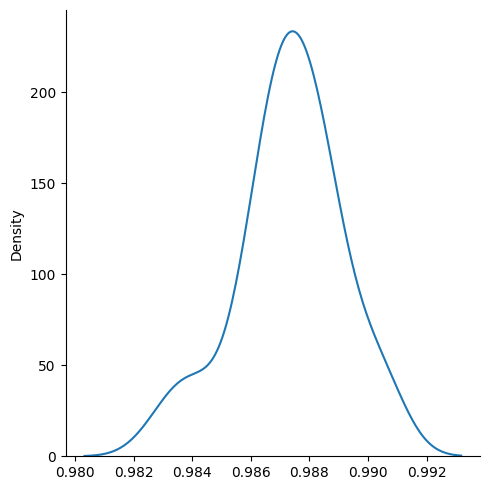

In [89]:
sns.displot(resultados_arvore, kind='kde')

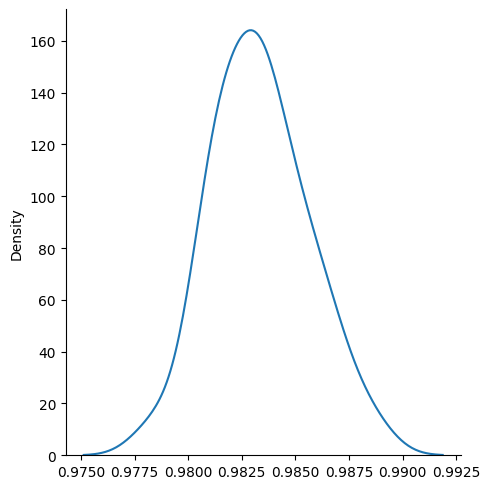

In [90]:
sns.displot(resultado_random_forest, kind='kde')

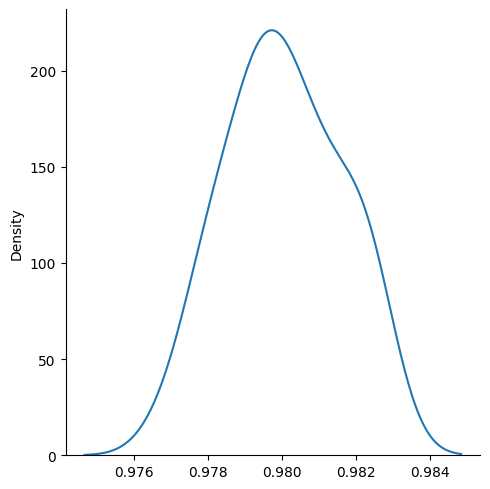

In [91]:
sns.displot(resultados_knn, kind='kde')

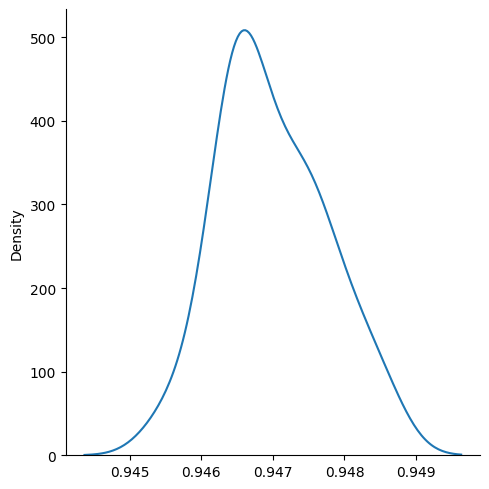

In [92]:
sns.displot(resultados_logistica, kind='kde')

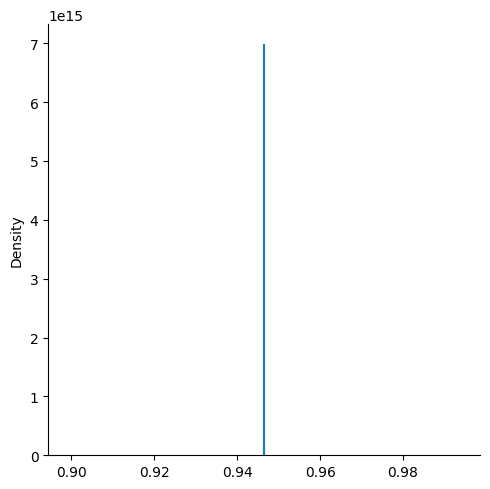

In [93]:
sns.displot(resultados_svm, kind='kde')

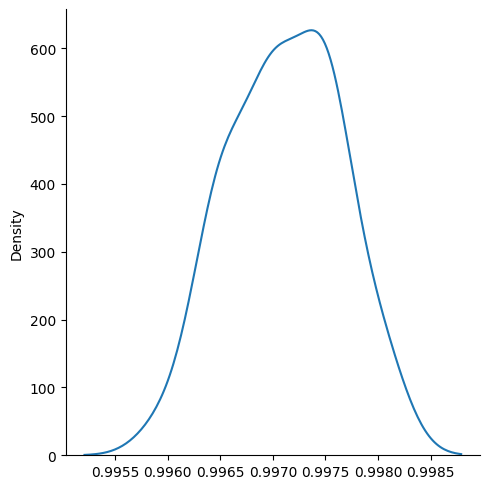

In [94]:
sns.displot(resultados_rna, kind='kde')

# Teste de Hipótese ANOVA

In [95]:
from scipy.stats import f_oneway

In [96]:
_, p = f_oneway(resultados_arvore, resultado_random_forest, resultados_knn, resultados_logistica, resultados_svm, resultados_rna)
print(p)

6.705446635228736e-201


In [97]:
alpha = 0.05
if(p<=alpha):
    print("Hipotese nula rejeitada. Dados são diferentes")
else:
    print("Hipótese alternativa rejeitada. Resultados são iguais")

Hipotese nula rejeitada. Dados são diferentes


In [98]:
resultados_algoritmos = {'accuracy': np.concatenate([resultados_arvore, resultado_random_forest, resultados_knn, resultados_logistica, resultados_svm, resultados_rna]), 'algoritmo':
                         ['arvore', 'arvore', 'arvore', 'arvore', 'arvore', 'arvore', 'arvore', 'arvore', 'arvore', 'arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore','arvore',
                          'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
                          'knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn','knn',
                          'logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica','logistica',
                          'svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm','svm',
                          'rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna','rna']}

In [99]:
resultados_df = pd.DataFrame(resultados_algoritmos)
resultados_df

,accuracy,algoritmo
0,0.9865,arvore
1,0.9840,arvore
2,0.9905,arvore
3,0.9875,arvore
4,0.9885,arvore
...,...,...
175,0.9980,rna
176,0.9970,rna
177,0.9970,rna
178,0.9965,rna


# Salvando o Modela para mandar para o desenvolvedor

In [100]:
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import pickle

In [101]:
classificador_rede_neural = MLPClassifier(activation='relu', batch_size=56, solver='adam')
classificador_rede_neural.fit(x_credit, y_credit)

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",56
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [102]:
classificador_arvore = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, splitter='best')
classificador_arvore.fit(x_credit, y_credit)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [136]:
classificador_svm = SVC(C=2.0, kernel='rbf', probability=True)
classificador_svm.fit(x_credit, y_credit)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [104]:
pickle.dump(classificador_rede_neural, open('rede_neural_finalizado.sav', 'wb'))

In [137]:
pickle.dump(classificador_svm, open('svm_finalizado.sav', 'wb'))

In [106]:
pickle.dump(classificador_rede_neural, open('arvore_finalizado.sav', 'wb'))

# Carregar um algoritmo já treinado

In [138]:
rede_neural = pickle.load(open('rede_neural_finalizado.sav', 'rb'))
arvore = pickle.load(open('arvore_finalizado.sav', 'rb'))
svm = pickle.load(open('svm_finalizado.sav', 'rb'))

In [145]:
novo_registro = x_credit[1999]
novo_registro

array([-1.03572293, -0.93978122,  0.04244312])

In [125]:
novo_registro.shape

(3,)

In [146]:
novo_registro = novo_registro.reshape(1, -1)

In [147]:
resposta_rna = rede_neural.predict(novo_registro)
resposta_arvore = arvore.predict(novo_registro)
resposta_svm = svm.predict(novo_registro)

In [148]:
resposta_rna, resposta_arvore, resposta_svm

(array([1]), array([1]), array([1]))

In [129]:
paga = 0
nao_paga = 0

if resposta_rna[0] == 1:
    nao_paga += 1
else:
    paga += 1

if resposta_arvore[0] == 1:
    nao_paga += 1
else:
    paga += 1

if resposta_svm[0] == 1:
    nao_paga += 1
else:
    paga += 1

if paga > nao_paga:
    print("O cliente pagará o empréstimo")
else:
    print("O cliente não pagará o empréstimo")

O cliente pagará o empréstimo


# Rejeição Classificadores

In [149]:
probabilidade_rna = rede_neural.predict_proba(novo_registro)
probabilidade_rna

array([[8.65841328e-05, 9.99913416e-01]])

In [150]:
confianca_rna = probabilidade_rna.max()
confianca_rna

np.float64(0.9999134158672082)

In [151]:
probabilidade_arvore = arvore.predict_proba(novo_registro)
confianca_arvore = probabilidade_arvore.max()
confianca_arvore

np.float64(0.9999134158672082)

In [152]:
probabilidade_svm = svm.predict_proba(novo_registro)
confianca_svm = probabilidade_svm.max()
confianca_svm

np.float64(0.9929074663967896)

In [153]:
paga = 0
algoritmos = 0
confianca_minima = 0.99998818013537613

if confianca_rna >= confianca_minima:
    algoritmos += 1

if confianca_arvore >= confianca_minima:
    algoritmos += 1

if confianca_svm >= confianca_minima:
    algoritmos += 1

print("O cliente pagará o empréstimo com base em " + str(algoritmos) + " algoritmos")

O cliente pagará o empréstimo com base em 0 algoritmos
